<a href="https://colab.research.google.com/github/livaage/nsbi-lhc-toolkit/blob/ml4hep-tifr-colab/workshops/ml4hep_tifr_colab/Exercise_2_2a_SigvsRef_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2.2a — Signal-vs-Reference density-ratio training

**Google Colab fallback.** Run the setup cell below **first** — it installs the
dependencies, pulls the `nsbi_common_utils` package plus the tutorial helpers
(`utils.py`, `generate_distributions.py`), generates the dataset, and moves into
the tutorial directory so everything below runs unchanged.

> 💡 For the training notebooks, switch to a **GPU runtime**
> (*Runtime → Change runtime type → GPU*) and consider lowering `number_of_epochs`
> / `N_TRAIN` for a quick pass.

> 💾 **This notebook is a *producer*.** Training below **saves** the density-ratio ensemble to **`models_SigvsRef/`** (ONNX weights + scaler). **`Exercise_2_3` loads exactly this folder** — it does not retrain. So that 2.3 can find it in a *separate* Colab runtime, set **`USE_DRIVE = True`** in the setup cell of **both** this notebook and 2.3 (mounts Google Drive so `models_SigvsRef/` persists).


In [ ]:
# ============================================================================
# Google Colab setup — run me first.  Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys

# --- config -----------------------------------------------------------------
REPO_URL = "https://github.com/livaage/nsbi-lhc-toolkit.git"  # package + tutorial helpers
BRANCH   = "ml4hep_school_tutorial"
N_BKG, N_SIG = 300_000, 300_000     # Colab-sized dataset (raise for less MC noise in the fit)
USE_DRIVE = False                   # True -> save data/models to Google Drive so they
                                    # persist across notebooks & sessions (see notes above)
# ----------------------------------------------------------------------------

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = "/content/drive/MyDrive/ml4hep_tifr_colab"
    else:
        ROOT = "/content"
    os.makedirs(ROOT, exist_ok=True)
    os.chdir(ROOT)

    # 1) fetch ONLY the package source + tutorial helpers (skip Git-LFS / big blobs)
    if not os.path.isdir("nsbi-lhc-toolkit"):
        os.environ["GIT_LFS_SKIP_SMUDGE"] = "1"
        !git clone --depth 1 --filter=blob:none --sparse --branch $BRANCH $REPO_URL
        !cd nsbi-lhc-toolkit && git sparse-checkout set src workshops/ml4hep_tifr

    # 2) make `import nsbi_common_utils` work (pure-python src layout, no build step)
    src = os.path.abspath("nsbi-lhc-toolkit/src")
    if src not in sys.path:
        sys.path.insert(0, src)

    # 3) runtime deps Colab doesn't already ship (torch/jax/sklearn/... are preinstalled)
    !pip install -q pytorch-lightning onnx onnxruntime onnxscript iminuit mplhep

    # 4) work from the tutorial dir so utils.py / generate_distributions.py and the
    #    ./dataframes, ./models_* relative paths resolve just like a local run
    os.chdir("nsbi-lhc-toolkit/workshops/ml4hep_tifr")

    # 5) generate the Gaussian-mixture samples if they aren't there yet
    if not os.path.exists("dataframes/signal.parquet"):
        !python generate_distributions.py --n_bkg $N_BKG --n_sig $N_SIG

print("Working dir:", os.getcwd())


Density Ratio Training - Signal vs Reference
---

In the 2a and 2b notebooks we will setup the neural networks that train unbiased and low-variance density ratios to be then used for building SBI model, which can be written as:

$$ \frac{L(\mu)}{\prod_e p_\mathrm{ref}(x_e)} = \prod_{x_e\in \{x\}} \frac{1}{\mu \cdot \lambda_\mathrm{sig} + \lambda_\mathrm{bkg}} \left[\mu \cdot \lambda_\mathrm{sig} \cdot \frac{p_\mathrm{sig}(x_e)}{p_\mathrm{ref}(x_e)} + \lambda_\mathrm{bkg} \cdot \frac{p_\mathrm{bkg}(x_e)}{p_\mathrm{ref}(x_e)}\right]$$

which we will then used to build the test statisti in the `3_parameter_fitting.ipynb` notebook. The ratios to estimate using NN are now:

$$ \hat{r}_\mathrm{sig}(x) = \frac{p_\mathrm{sig}(x)}{p_\mathrm{ref}(x)}, \qquad  \hat{r}_\mathrm{bkg}(x) = \frac{p_\mathrm{bkg}(x)}{p_\mathrm{ref}(x)} $$


In this notebook we will use the `nsbi-common-utils` to estimate $\hat{r}_\mathrm{sig}(x)$ via neural networks. Because the underlying densities are Gaussian *mixtures* with overlapping support, the classifier score stays bounded away from 0 and 1 and the resulting ratio is numerically stable.

In [1]:
import pandas as pd
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt

Insert the path to the downloaded dataset (see README for download link)

In [2]:
BASE_PATH = "./dataframes/"

Load the signal and background datasets

In [3]:
signal = pd.read_parquet(f"{BASE_PATH}/signal.parquet")
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

### Train / inference split

The density ratios must be **trained** and the likelihood **evaluated** on *different* events, otherwise the parameter fit inherits the classifier's overfitting. We split each sample with a fixed seed: the training notebooks (2a, 2b) keep the *training* half and the fitting notebook (3) keeps the *inference* half.

`SPLIT_SEED` and `TRAIN_FRACTION` **must be identical across all three notebooks** — the shared seed is what guarantees the two halves are disjoint. Change `TRAIN_FRACTION` (or pass `n_train=<int>` to `split_train_inference`) to adjust how many events go to training vs. inference.

In [4]:
from utils import split_train_inference

SPLIT_SEED = 0
TRAIN_FRACTION = 0.5  # fraction of each sample used for TRAINING

signal, _ = split_train_inference(signal, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)
background, _ = split_train_inference(background, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)

print(f"Training on {len(signal):,} signal + {len(background):,} background events")

Training on 2,500,000 signal + 2,500,000 background events


We will use the full high-dimensional feature space to train the density ratios

In [5]:
training_features = ["x1", "x2", "x3", "x4", "x5"]

The numerator and denominator hypothesis refer to the signal and reference hypothesis respectively for this notebook. Remember, the objective is to train a model that estimates

$$ \hat{r}_\mathrm{sig}(x) = \frac{p_\mathrm{sig}(x)}{p_\mathrm{ref}(x)} $$

We will choose the reference hypothesis to be a combination of the signal and background so there are no phase space regions with $p_\mathrm{ref}(x) \approx 0$ during training.

The choice of reference is one of the difficult and less well-defined parts of the SBI approach -  it has significant impact on numerical stability.

In [6]:
numerator_hypothesis = signal.astype('float32').copy()
denominator_hypothesis = pd.concat([background, signal], ignore_index=True).astype('float32').copy()

Build a combined training dataset consisting of events from numerator and denominator hypothesis. By using `weights_normed` the binary cross-entropy loss function sees both classes represented equally, allowing us to use the likelihood-ratio trick for density ratio estimation. `train_labels` correspond to the truth labels that go into the binary cross-entropy loss function.

In [7]:
numerator_hypothesis["weights"] = numerator_hypothesis['weight']
numerator_hypothesis["weights_normed"] = numerator_hypothesis['weight'] / numerator_hypothesis['weight'].sum()
numerator_hypothesis["train_labels"] = 1.0

denominator_hypothesis["weights"] = denominator_hypothesis['weight']
denominator_hypothesis["weights_normed"] = denominator_hypothesis['weight'] / denominator_hypothesis['weight'].sum()
denominator_hypothesis["train_labels"] = 0.0

Select a subset of events to train on

In [8]:
N_TRAIN = 1_500_000  # None = use all events

training_dataframe = pd.concat([numerator_hypothesis, denominator_hypothesis], ignore_index=True)
training_dataframe = training_dataframe.sample(frac=1, random_state=42, ignore_index=True)

if N_TRAIN is not None:
    training_dataframe = training_dataframe.head(N_TRAIN).reset_index(drop=True)
    # Re-normalize per-class weights so each class still sums to 1 after subsetting
    for label_val in [0.0, 1.0]:
        mask = training_dataframe["train_labels"] == label_val
        training_dataframe.loc[mask, "weights_normed"] = (
            training_dataframe.loc[mask, "weight"]
            / training_dataframe.loc[mask, "weight"].sum()
        )

### Neural Network Training

In [9]:
ensemble_size = 1

### 💾 Saving the trained models → `models_SigvsRef/`
The `density_ratio_trainer(...)` below is configured with `path_to_models="models_SigvsRef/"`, and the `.train(...)` call writes the ONNX weights + scaler there. **`Exercise_2_3` reads this exact folder.** For 2.3 to pick it up in a separate Colab runtime, make sure `USE_DRIVE = True` was set in the setup cell so `models_SigvsRef/` lands on your Google Drive.


In [10]:
from nsbi_common_utils.training import density_ratio_trainer

trainer = [None for i in range(ensemble_size)]

for ens_index in range(ensemble_size):
    trainer[ens_index] = density_ratio_trainer(
        dataset=training_dataframe,
        weights=training_dataframe["weights_normed"],
        training_labels=training_dataframe["train_labels"],
        features=training_features,
        features_scaling=training_features,
        sample_name=["signal", "reference"],
        output_name="",
        path_to_figures="plots_SigvsRef/",
        path_to_models="models_SigvsRef/",
    )

### HyperParameters

The default parameters build a wide multi-layer perceptron (MLP) that has been optimized for estimating well-calibrated and unbiased density ratios in most cases.

Exercise: try changing hyperparameters like hidden_layers or neurons or batch_size and see what results you get - both in terms of diagnostics and final parameter fits.

In [16]:
for ens_index in range(ensemble_size):

    trainer[ens_index].train(
        hidden_layers=4,
        neurons=1024,
        number_of_epochs=50,
        batch_size=1024,
        learning_rate=1e-3,
        scalerType="MinMax",
        ensemble_index=ens_index,
        verbose=1,
        holdout_split=0.25, # validation
        validation_split=0.2,
        callback_patience=10,
        num_workers=4,
        load_trained_models=False,
        calibration=False,
        type_of_calibration = "histogram",
        recalibrate_output=True,
        num_bins_cal = 50
    )

2026-07-06 15:28:21 | INFO | Training Logs | Sum of weights of class 0: 0.7496853247828708
2026-07-06 15:28:21 | INFO | Training Logs | Sum of weights of class 1: 0.750000437910785
2026-07-06 15:28:21 | INFO | Training Logs | Using swish activation function
2026-07-06 15:28:21 | INFO | Training Logs | Setting log loss to False
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/jaysandesara/Downloads/nsbi-lhc-toolkit/workshops/ml4hep_tifr/checkpoints exists and is not empty.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch    0 | lr = 1.000e-03 | val_loss = 0.692940 | 


...

Epoch    0 | lr = 1.000e-03 | val_loss = 0.465946 | 
Epoch    1 | lr = 1.000e-03 | train_loss = 0.491909 | val_loss = 0.463705 | 
Epoch    2 | lr = 1.000e-03 | train_loss = 0.464022 | val_loss = 0.463898 | 
Epoch    3 | lr = 1.000e-03 | train_loss = 0.462380 | val_loss = 0.463352 | 
Epoch    4 | lr = 1.000e-03 | train_loss = 0.461516 | val_loss = 0.462052 | 
Epoch    5 | lr = 1.000e-03 | train_loss = 0.461057 | val_loss = 0.462289 | 
Epoch    6 | lr = 1.000e-03 | train_loss = 0.460762 | val_loss = 0.462446 | 
Epoch    7 | lr = 1.000e-03 | train_loss = 0.460509 | val_loss = 0.462675 | 
Epoch    8 | lr = 1.000e-03 | train_loss = 0.460331 | val_loss = 0.462360 | 
Epoch    9 | lr = 1.000e-05 | train_loss = 0.460194 | val_loss = 0.461545 | 
Epoch   10 | lr = 1.000e-05 | train_loss = 0.459868 | val_loss = 0.460489 | 
Epoch   11 | lr = 1.000e-05 | train_loss = 0.458154 | val_loss = 0.460295 | 
Epoch   12 | lr = 1.000e-05 | train_loss = 0.457608 | val_loss = 0.460191 | 
Epoch   13 | lr = 1.000

2026-07-06 15:51:01 | INFO | Training Logs | Finished Training
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/training/utils.py:91: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0706 15:51:01.872000 71364 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0706 15:51:02.048000 71364 site-packages/torch/onnx/_internal/exporter/_registration.py:

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
2026-07-06 15:53:37 | INFO | Training Logs | reference training data has min ratio 0.0026407353579998016
2026-07-06 15:53:37 | INFO | Training Logs | reference training data has max ratio 195.7447967529297
2026-07-06 15:53:37 | INFO | Training Logs | signal training data has min ra

<Figure size 800x600 with 0 Axes>

Diagnostic Checks
===

While traditionally, a NN observable is judged on the basis of its accuracy - for NSBI we are interested in the quality of the density ratios more than the discrimination power. The latter comes from the perfect modelling of the multi-dimensional likelihood ratios.

To ensure correct modelling, we run two main checks on the training:

- **Calibration closure test**

  The NNs are trained using the binary cross-entropy loss, which under ideal conditions leads to the NN converging to the score function:

  $$\hat{s}_\text{pred} = \frac{p_\text{s}(x)}{p_\text{ref}(x)+p_\text{s}(x)}$$

  that can be converted into the probability ratio we desire (likelihood ratio trick):

  $$\frac{p_\text{s}(x)}{p_\text{ref}(x)} = \frac{\hat{s}_\text{pred}(x)}{1-\hat{s}_\text{pred}(x)}$$

  For the NNs to be well-calibrated, we use the Monte Carlo samples to verify the equality:


  $$\left[\frac{p_s(x)}{p_s(x)+p_{ref}(x)}\right]_\text{NN} \sim \left[\frac{\mathcal{N}_s^{I(x|\hat{s}_\text{pred})}}{\mathcal{N}_s^{I(x|\hat{s}_\text{pred})}+\mathcal{N}_\text{ref}^{I(x|\hat{s}_\text{pred})}}\right]_\text{MC}$$

  where we bin the events from $p_c$ and $p_\text{ref}$ MC samples, denoted by $\mathcal{N}_s^{I(x|\hat{s}_\text{pred})}$ and $\mathcal{N}_\text{ref}^{I(x|\hat{s}_\text{pred})}$ respectively where $I(x|\hat{s}_\text{pred})$ returns the index of the $\hat{s}_\text{pred}$ bin in which an event $x$ falls.
 


In [17]:
ens_index_to_plot = 0

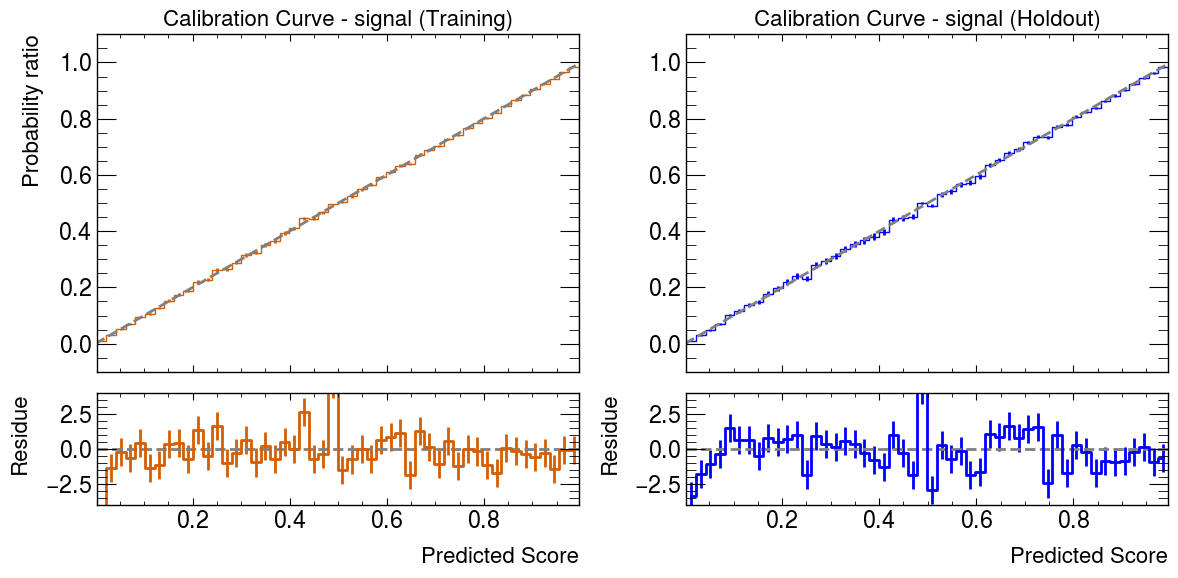

<Figure size 800x600 with 0 Axes>

In [18]:
trainer[ens_index_to_plot].make_calib_plots(observable='score', nbins=50, ensemble_index=0)

## Density ratio reweighting closure tests
  
Despite having a well-calibrated output and thus a robust probabilistic interpretation, the trained density ratios might not capture the full multi-dimensional event information $x$. 

The next diagnostic involves verifying the following equality using 1D projections of $x$:

$$\frac{p_s(x)}{p_{ref}(x)} \times p_{ref}(x) \sim p_s(x)$$

We can do this one-by-one for all the observables used to model the density ratios, and also possibly the observables not used directly in the training but can still be well-estimated due to the NN learning the right physics.

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:318: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


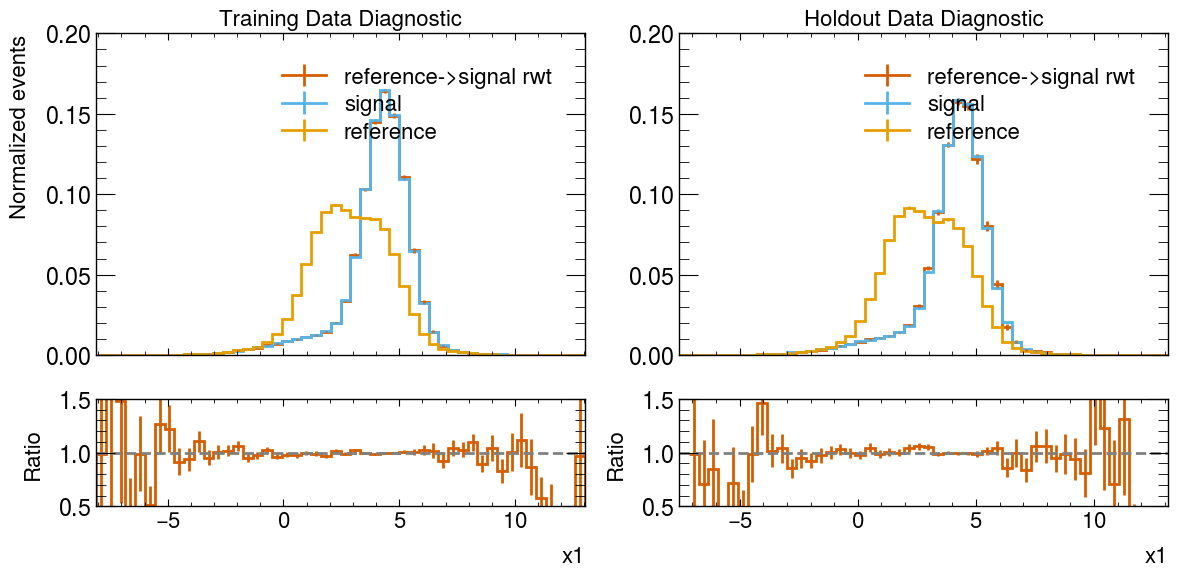

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:318: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


<Figure size 800x600 with 0 Axes>

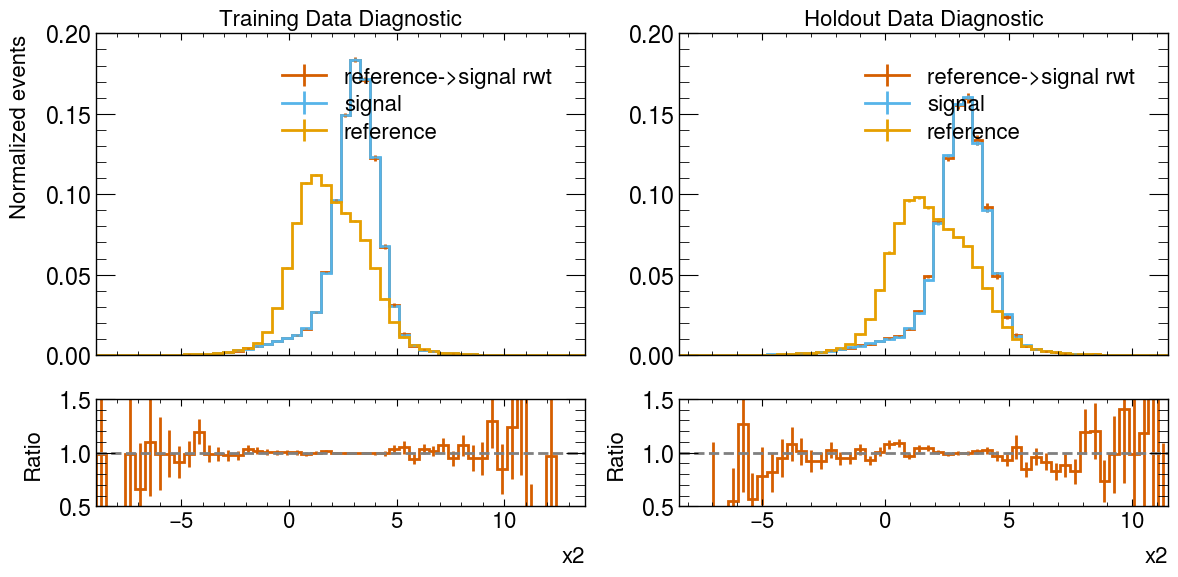

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/j

<Figure size 800x600 with 0 Axes>

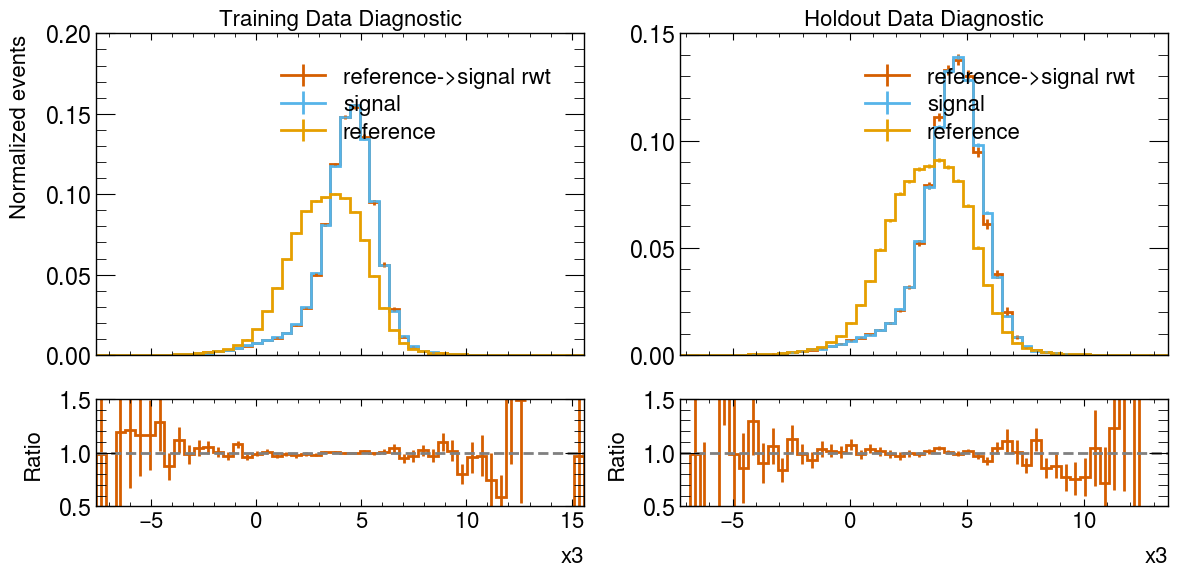

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/j

<Figure size 800x600 with 0 Axes>

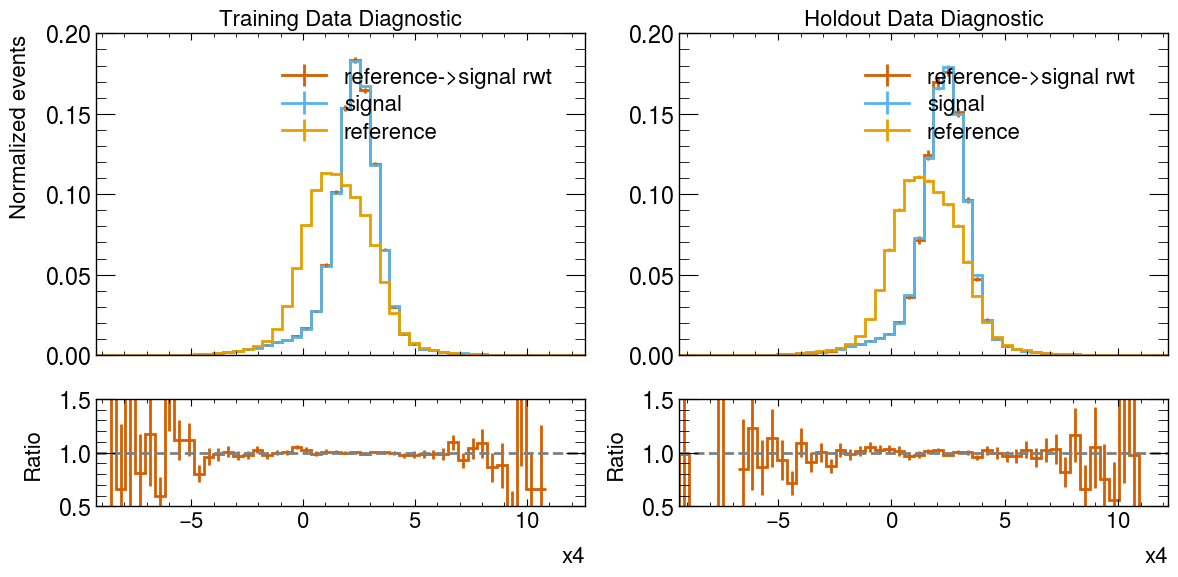

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:318: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


<Figure size 800x600 with 0 Axes>

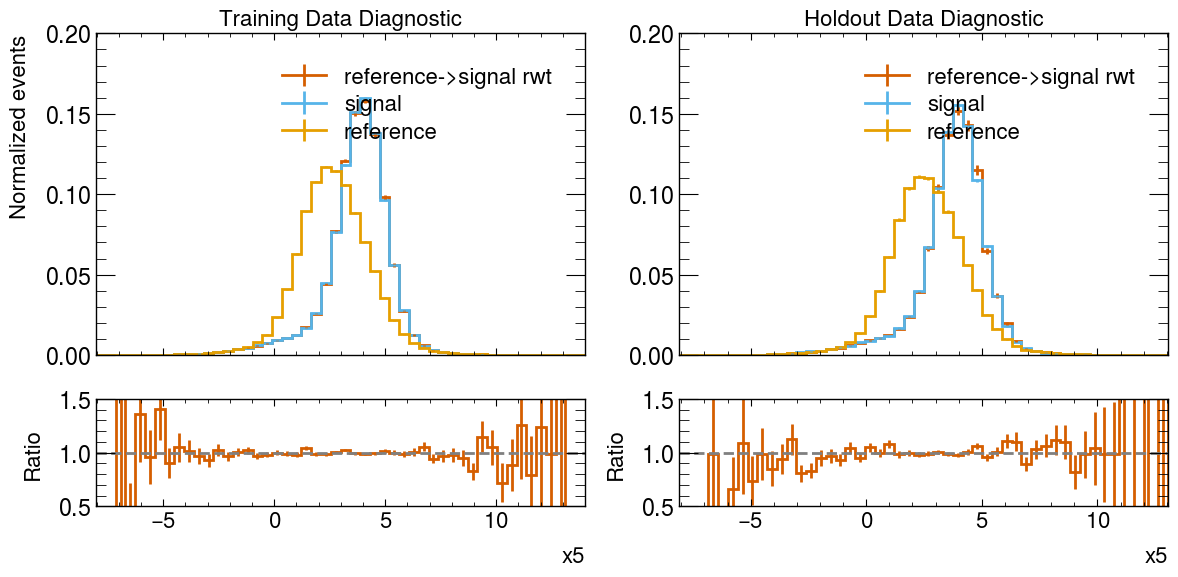

<Figure size 800x600 with 0 Axes>

In [19]:
trainer[ens_index_to_plot].make_reweighted_plots(training_features, "linear", 50)